### 测试图片识别模型

In [64]:
from autogluon.multimodal import MultiModalPredictor
from PIL import Image
from ultralytics import YOLO

In [29]:
model_dict={
    "eye_disease":{
        "DN":{
            "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/DN"),
            "label":"脉络膜小疣"
        },
        "DR":{
            "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/DR"),
            "label":"糖网病"
        },
        "MH":{
            "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/MH"),
            "label":"屈光介质混浊"
        },
        "Normal":{
            "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/Normal"),
            "label":"正常"
        },
        "ODC":{
            "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/ODC"),
            "label":"视神经盘凹陷"
        },
        "TSLN":{
            "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/TSLN"),
            "label":"豹纹状病变"
        }
    },
    "skin_cancer":{
        "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/Skin_Cancer"),
        "label":"皮肤癌"
    },
    "chest_cancer":{
        "model":MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/chest_cancer_detection"),
        "label":"胸部肿瘤"
    },
    "breast_cancer":{
        "model":YOLO("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/breast_cancer_detection/breast_cancer_detection/weights/best.pt"),
        "label":"乳腺癌"
    }
}

Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/DN/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/DR/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/MH/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/Normal/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/ODC/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/TSLN/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/Skin_Cancer/model.ckpt
Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/model

In [65]:
def Imageprediction(image_path,img_type,model_dict):
    if img_type == "eye_disease":
        info = "眼底疾病风险评估结果："
        # 先预测是否正常
        predictions = model_dict['eye_disease']['Normal']['model'].predict({'image': [image_path]})[0]
        proba = model_dict['eye_disease']['Normal']['model'].predict_proba({'image': [image_path]})[0]
        if predictions == 1:
            return {"info":info,"label":"Healthy"}
        else:
            for key,value in model_dict['eye_disease'].items():
                if key != "Normal":
                    predictions = value['model'].predict({'image': [image_path]})[0]
                    proba = value['model'].predict_proba({'image': [image_path]})[0]
                    if predictions == 1:
                        info += value['label']+",概率"+str(proba[predictions])+"，"
            if info.endswith("，"):
                info = info[:-1]
            return {"info":info,"label":"No Healthy"}
    elif img_type == "skin_cancer":
        info = "皮肤癌风险评估结果："
        predictions = model_dict['skin_cancer']['model'].predict({'image': [image_path]})[0]
        proba = model_dict['skin_cancer']['model'].predict_proba({'image': [image_path]})[0]
        if predictions == 0:
            info += "光化性角化病,概率"+str(proba[predictions])
        elif predictions == 1:
            info += "基底细胞癌,概率"+str(proba[predictions])
        elif predictions == 2:
            info += "良性角化病样病变,概率"+str(proba[predictions])
        elif predictions == 3:
            info += "皮肤纤维瘤,概率"+str(proba[predictions])
        elif predictions == 4:
            info += "黑色素瘤,概率"+str(proba[predictions])
        elif predictions == 5:
            info += "黑色素细胞痣,概率"+str(proba[predictions])
        elif predictions == 6:
            info += "血管病变,概率"+str(proba[predictions])
        return {"info":info,"label":"No Healthy"}
    elif img_type == "chest_cancer":
        info = "胸部肿瘤风险评估结果："
        predictions = model_dict['chest_cancer']['model'].predict({'image': [image_path]})[0]
        proba = model_dict['chest_cancer']['model'].predict_proba({'image': [image_path]})[0]
        if predictions == 0:
            return {"info":info,"label":"Healthy"}
        elif predictions == 1:
            info += "腺癌,概率"+str(proba[predictions])
        elif predictions == 2:
            info += "大细胞癌,概率"+str(proba[predictions])
        elif predictions == 3:
            info += "鳞状细胞癌,概率"+str(proba[predictions])
        return {"info":info,"label":"No Healthy"}
    elif img_type == "breast_cancer":
        info = "乳腺癌风险评估结果："
        results=model_dict['breast_cancer']['model'].predict(image_path)[0]
        results_cls=results.boxes.cls.to("cpu").tolist()
        results_conf=results.boxes.conf.to("cpu").tolist()
        for i in range(len(results_cls)):
            if results_cls[i] == 1:
                info += "良性肿瘤,概率"+str(results_conf[i])
            elif results_cls[i] == 2:
                info += "恶性肿瘤,概率"+str(results_conf[i])
            elif results_cls[i] == 0:
                info += "健康,概率"+str(results_conf[i])
        im_bgr = results.plot()
        im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image

        return {"results":results,"info":info,"label":"Analyzed","image":im_rgb}
    return {"info":"","label":"Other"}

results=Imageprediction("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/data/Img/Breast_cancer/yolo_dataset/images/train/benign (4).png","breast_cancer",model_dict)


image 1/1 /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/data/Img/Breast_cancer/yolo_dataset/images/train/benign (4).png: 544x640 2 benigns, 16.4ms
Speed: 4.7ms preprocess, 16.4ms inference, 8.1ms postprocess per image at shape (1, 3, 544, 640)


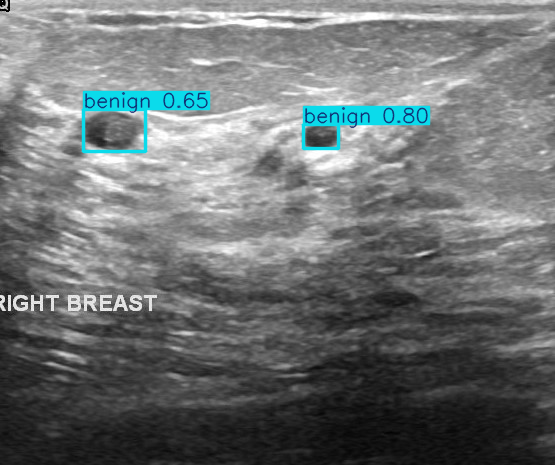

In [68]:
results['image']

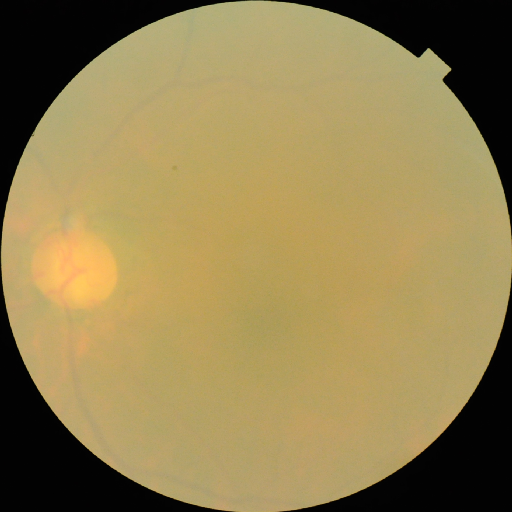

In [5]:
image_path ="/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/data/Img/eye_disease/train_upsampled/4.png"
pil_img = Image(filename=image_path)
display(pil_img)

In [6]:
predictor = MultiModalPredictor.load("/home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/DN")
predictions = predictor.predict({'image': [image_path]})

Load pretrained checkpoint: /home/dxye/Program/PhysicalExaminationAgent/client/risk_assessment/models/eye_disease/DN/model.ckpt
/home/dxye/miniconda3/envs/baichuanm1/lib/python3.10/site-packages/autogluon/multimodal/learners/base.py:2117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full co

Predicting: |          | 0/? [00:00<?, ?it/s]

In [8]:
proba = predictor.predict_proba({'image': [image_path]})
print(proba)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.


Predicting: |          | 0/? [00:00<?, ?it/s]

[[0.99771726 0.00228278]]
